In [ ]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data

nodes_df = pd.read_csv("../pre_processing_output/classification_three_labels_nodes_sim_main_components.csv")  # Dataset con nodi (proteine)

nodes_df['features'] = nodes_df['features'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.int))

common_nodes = set(nodes_df[nodes_df['label'] == 2]['name'].to_list())
nodes_df = nodes_df[~nodes_df['name'].isin(common_nodes)]

name_id_dict = dict(zip(nodes_df['id'], nodes_df['name']))
print(name_id_dict)

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['id'], x=row['features'], y=torch.tensor(row['label'], dtype=torch.long))

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])
)

# data riassegna gli indici delle proteine passate. Faccio questo dict per statistiche dopo
index_to_name = {i: name_id_dict[n_id] for i, n_id in enumerate(G.nodes) if n_id in name_id_dict}

print(data)

{0: '9606.ENSP00000485513', 1: '9606.ENSP00000299138', 3: '9606.ENSP00000428968', 4: '9606.ENSP00000317473', 5: '9606.ENSP00000447300', 6: '9606.ENSP00000366070', 8: '9606.ENSP00000391311', 9: '9606.ENSP00000448182', 10: '9606.ENSP00000321971', 11: '9606.ENSP00000261367', 12: '9606.ENSP00000351132', 13: '9606.ENSP00000400184', 14: '9606.ENSP00000367346', 15: '9606.ENSP00000296597', 16: '9606.ENSP00000358272', 17: '9606.ENSP00000351737', 18: '9606.ENSP00000323076', 19: '9606.ENSP00000497587', 20: '9606.ENSP00000355206', 21: '9606.ENSP00000392709', 22: '9606.ENSP00000356972', 23: '9606.ENSP00000360492', 24: '9606.ENSP00000482543', 25: '9606.ENSP00000407336', 26: '9606.ENSP00000389160', 27: '9606.ENSP00000418803', 28: '9606.ENSP00000354665', 29: '9606.ENSP00000340278', 30: '9606.ENSP00000330737', 31: '9606.ENSP00000327268', 32: '9606.ENSP00000315774', 33: '9606.ENSP00000299166', 34: '9606.ENSP00000296684', 35: '9606.ENSP00000281031', 36: '9606.ENSP00000276689', 37: '9606.ENSP00000276062',

/tmp/ipykernel_44651/1028129419.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['id'], x=row['features'], y=torch.tensor(row['label'], dtype=torch.long))


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim

class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0):
        super(MLP, self).__init__()

        self.__in_channels = in_channels
        self.__hidden_channels = hidden_channels
        self.__out_channels = out_channels
        self.__dropout = dropout
        
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x.view(-1)  # Output logits for BCEWithLogitsLoss()
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10, log=True):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x)  # Forward pass
            train_loss = criterion(out[data.train_mask], data.y[data.train_mask].float())  # Convert target to float
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x[data.val_mask])
                val_loss = criterion(val_out, data.y[data.val_mask].float())
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if log: print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0:
                if log: print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        # Plot training and validation loss
        if log:
            plt.figure()
            plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
            plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Training & Validation Loss Curve')
            plt.legend()
            plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=100, learning_rate=0.001, patience=10, log=True):
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None
        best_train_indices = None  # Salverà gli indici originali del miglior training set

        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x, data.y.cpu().numpy())):
            if log:
                print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            data.train_mask = train_mask
            data.val_mask = val_mask

            model = MLP(in_channels=self.__in_channels, 
                        hidden_channels=self.__hidden_channels, 
                        out_channels=self.__out_channels, 
                        dropout=self.__dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.BCEWithLogitsLoss()
            model.train_model(data, optimizer, criterion, epochs, patience, log=False)

            model.eval()
            with torch.no_grad():
                out = model(data.x)
                out = torch.sigmoid(out)  # Apply sigmoid for binary classification
                pred = (out[val_mask] > 0.5).int()
                y_true = data.y[val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                if log:
                    print(f"Accuracy: {acc:.4f}")
                    print(f"Precision: {precision:.4f}")
                    print(f"Recall: {recall:.4f}")
                    print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1
                    }
                    best_cm = cm
                    best_train_indices = train_idx  # Salviamo gli indici del miglior training set

        if log:
            print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
            print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
            print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
            print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
            print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
            
            print("\n📊 **Prestazioni del miglior modello nella sua fold di validazione**")
            for metric, value in best_fold_metrics.items():
                print(f"{metric}: {value:.4f}")
            
            # Plot confusion matrix for best model
            if best_cm is not None:
                plt.figure(figsize=(4,4))
                sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
                plt.xlabel("Predicted")
                plt.ylabel("Actual")
                plt.title("Confusion Matrix of Best Model")
                plt.show()

        return best_model, best_fold_metrics





🔹 Fold 1/5
Accuracy: 0.7941
Precision: 0.9000
Recall: 0.6000
F1-Score: 0.7200

🔹 Fold 2/5
Accuracy: 0.6765
Precision: 0.7500
Recall: 0.4000
F1-Score: 0.5217

🔹 Fold 3/5
Accuracy: 0.7273
Precision: 0.8000
Recall: 0.5333
F1-Score: 0.6400

🔹 Fold 4/5
Accuracy: 0.9091
Precision: 0.9286
Recall: 0.8667
F1-Score: 0.8966

🔹 Fold 5/5
Accuracy: 0.7273
Precision: 1.0000
Recall: 0.4000
F1-Score: 0.5714

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.7668 ± 0.0803
Precision: 0.8757 ± 0.0899
Recall: 0.5600 ± 0.1718
F1-Score: 0.6699 ± 0.1315

📊 **Prestazioni del miglior modello nella sua fold di validazione**
Accuracy: 0.9091
Precision: 0.9286
Recall: 0.8667
F1-Score: 0.8966


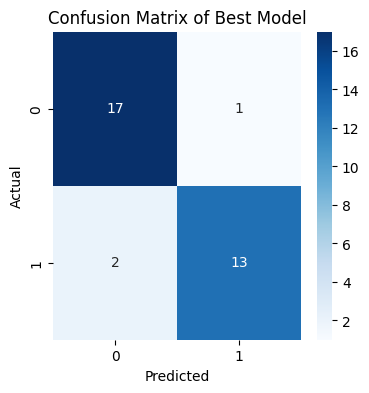

In [19]:
LR = 0.001
model = MLP(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
_, best_training_mask = model.k_fold_cross_validation(data,epochs=50, learning_rate=LR, patience=10)
# print(best_training_mask)

In [20]:
# Questo codice serve per controllare la frequenza dei sample nella fold con più alte metriche

DEBUG = True

if DEBUG:
    from torch.optim import Adam
    from tqdm import tqdm
    import numpy as np

    NUM_ITERATIONS = 100
    LR = 0.001

    best_metrics_list = []

    with tqdm(total=NUM_ITERATIONS, desc="Training Progress", unit="iteration") as pbar:
        for _ in range(NUM_ITERATIONS):
            model = MLP(in_channels=data.x.shape[1], hidden_channels=64, out_channels=1, dropout=0)
            optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)

            _, best_metrics = model.k_fold_cross_validation(data, k=5, epochs=50, learning_rate=LR, patience=10, log=False)
            best_metrics_list.append(best_metrics)
            pbar.update(1)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    avg_metrics = {}
    std_metrics = {}
    for m in metrics:
        avg_metrics[m] = np.mean([metric[m] for metric in best_metrics_list], dtype='float64')
        std_metrics[m] = np.std([metric[m] for metric in best_metrics_list], dtype='float64')

    print('Average metrics over 100 iterations')
    for metric in metrics:
        print(f'{metric} = {avg_metrics[metric]:.5f} {std_metrics[metric]:.5f}')



Training Progress: 100%|██████████| 100/100 [00:29<00:00,  3.44iteration/s]

Average metrics over 100 iterations
Accuracy = 0.83791 0.03397
Precision = 0.93423 0.06390
Recall = 0.69200 0.06978
F1-Score = 0.79172 0.04667
